# Functional connectivity analysis
Now fixating the number of seconds in the correlation window - 12 seconds around the transition

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# Settings
#data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
#tc_dir = os.path.join(data_dir,'derivatives','timecourses')

data_dir = os.path.join('..','data','bids_events')
tc_dir = os.path.join('..','data','timecourses')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['UA']
hrf_delay = 0 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [3]:
window_size_list = [6, 6, 6, 7.5] # in seconds (for each tr)
window_size_tr_list = [12, 8, 6, 3] # in tr (for each tr
step_size_list = [1, 1, 1, 1] # in seconds (for each tr)

In [5]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

df = pd.DataFrame(columns=['subject','tr','run',
                           'left_mt','right_mt','left_v1','right_v1',
                           'bilateral_mt','bilateral_v1',
                           'corr_mt','corr_v1',
                           'corr_mt_coherent','corr_v1_coherent','corr_mt_incoherent','corr_v1_incoherent',
                            'n_coherent','n_incoherent',
                           'feedback_mt_indexoffirstone_coherent',#'feedback_v1_indexoffirstone_coherent',
                           'feedback_mt_indexoffirstone_incoherent',#'feedback_v1_indexoffirstone_incoherent',
                           'feedback_mt_bolean_coherent',#'feedback_v1_bolean_coherent',
                           'feedback_mt_bolean_incoherent',#'feedback_v1_bolean_incoherent',
                           'feedback_mt_coherent',#'feedback_v1_coherent',
                           'feedback_mt_incoherent',#'feedback_v1_incoherent',
                            'n_ps_detected_mt_coherent',#'n_ps_detected_v1_coherent',
                            'n_ps_detected_mt_incoherent',#'n_ps_detected_v1_incoherent',
                           ])

# iterate over subjects
for ss,subject in enumerate(subject_list):

    print(f'Processing subject {subject} ({ss+1}/{len(subject_list)})')

    # iterate over trs
    for tt,tr in enumerate(tr_list):

        window_size_tr = window_size_tr_list[tt] # size of the correlation window in volumes
        step_size_tr = step_size_list[tt] # step size of the correlation window in volumes

        # iterate over runs
        for rr,run in enumerate(run_list):

            # load timecourse
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-psc_detrend.npy")
            tc = np.load(tc_file)

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # ----------------------------------------------------------------------------------------------------------------------------  

            # initialize correlation vectors
            corr_mt = np.zeros(int((tc[:,0].shape[0]-window_size_tr)/step_size_tr))
            corr_v1 = np.zeros(int((tc[:,0].shape[0]-window_size_tr)/step_size_tr))

            # estimate windowed correlation between left and right mt
            for tt,tt_vol in enumerate(range(0,tc[:,0].shape[0]-window_size_tr,step_size_tr)):
                corr_mt[tt] = np.corrcoef(tc[:,0][tt_vol:tt_vol+window_size_tr],tc[:,1][tt_vol:tt_vol+window_size_tr])[0,1]
                corr_v1[tt] = np.corrcoef(tc[:,2][tt_vol:tt_vol+window_size_tr],tc[:,3][tt_vol:tt_vol+window_size_tr])[0,1]

            # ----------------------------------------------------------------------------------------------------------------------------  
            
            # fetch events file
            task_label = f'task-{run}_acq-{round(tr*1000):04}_run-1'
            events_file = os.path.join(data_dir, subject, 'func', f'{subject}_{task_label}_events.tsv')

            events = pd.read_csv(events_file, sep='\t')

            # trim events to coherent and incoherent trial_types
            events = events.loc[events['trial_type'].isin(['coherent','incoherent'])]
            events = events.reset_index(drop=True)

            # trim events with duration < 7.5 seconds
            events = events.loc[events['duration']>=7.5]
            events = events.reset_index(drop=True)

            # get the indexes (based on the TR) for all coherent and incoherent trials
            coherent_idx = events.loc[events['trial_type']=='coherent']['onset'].values/tr
            coherent_idx = [int(x) for x in coherent_idx]
            incoherent_idx = events.loc[events['trial_type']=='incoherent']['onset'].values/tr
            incoherent_idx = [int(x) for x in incoherent_idx]

            # number of coherent trials
            n_coherent = len(coherent_idx)
            n_incoherent = len(incoherent_idx)

            # ----------------------------------------------------------------------------------------------------------------------------  

            # initialize correlation vectors for coherent and incoherent trials
            corr_mt_coherent = np.zeros((n_coherent,window_size_tr*2+1))
            corr_v1_coherent = np.zeros((n_coherent,window_size_tr*2+1))
            corr_mt_incoherent = np.zeros((n_incoherent,window_size_tr*2+1))
            corr_v1_incoherent = np.zeros((n_incoherent,window_size_tr*2+1))

            # initalize feedback signal vectors
            n_points_to_consider = window_size_tr*2 - 1
            feedback_mt_coherent = np.zeros((n_coherent,n_points_to_consider))
            feedback_mt_bolean_coherent = np.zeros((n_coherent,n_points_to_consider))
            feedback_mt_indexoffirstone_coherent = np.zeros((n_coherent,1))
            feedback_mt_incoherent = np.zeros((n_incoherent,n_points_to_consider))
            feedback_mt_bolean_incoherent = np.zeros((n_incoherent,n_points_to_consider))
            feedback_mt_indexoffirstone_incoherent = np.zeros((n_incoherent,1))

            # feedback_v1_coherent = np.zeros((n_coherent,n_points_to_consider))
            # feedback_v1_bolean_coherent = np.zeros((n_coherent,n_points_to_consider))
            # feedback_v1_indexoffirstone_coherent = np.zeros((n_coherent,1))
            # feedback_v1_incoherent = np.zeros((n_incoherent,n_points_to_consider))
            # feedback_v1_bolean_incoherent = np.zeros((n_incoherent,n_points_to_consider))
            # feedback_v1_indexoffirstone_incoherent = np.zeros((n_incoherent,1))

            # iterate on the number of coherent trials
            for jj,coh_idx in enumerate(coherent_idx):

                # left_mt timecourse
                a = tc[:,0][coh_idx-window_size_tr:coh_idx+window_size_tr*2]
                # right_mt timecourse
                b = tc[:,1][coh_idx-window_size_tr:coh_idx+window_size_tr*2]
                # left_v1 timecourse
                c = tc[:,2][coh_idx-window_size_tr:coh_idx+window_size_tr*2]
                # right_v1 timecourse
                d = tc[:,3][coh_idx-window_size_tr:coh_idx+window_size_tr*2]

                # correlation per window of window_size_tr
                for kk in range(0,window_size_tr*2+1):
                    corr_mt_coherent[jj,kk] = np.corrcoef(a[kk:kk+window_size_tr],b[kk:kk+window_size_tr])[0,1]
                    corr_v1_coherent[jj,kk] = np.corrcoef(c[kk:kk+window_size_tr],d[kk:kk+window_size_tr])[0,1]

                # estimate feedback signal - variation of correlation in relation to the 2nd correlation window (the first that includes the perceptual switch volume)
                feedback_mt_coherent[jj,:] = (corr_mt_coherent[jj,1:-1] - corr_mt_coherent[jj,1]) / corr_mt_coherent[jj,1]
                feedback_mt_bolean_coherent[jj,:] = feedback_mt_coherent[jj,:] > 0.1

                # feedback_v1_coherent[jj,:] = (corr_v1_coherent[jj,1:-1] - corr_v1_coherent[jj,1]) / corr_v1_coherent[jj,1]
                # feedback_v1_bolean_coherent[jj,:] = feedback_v1_coherent[jj,:] > 0.1

                # if feedback_mt_bolean_coherent is not all zeros, find the index of the first one and save it to feedback_mt_indexoffirstone_coherent
                if np.sum(feedback_mt_bolean_coherent[jj]) > 0:
                    feedback_mt_indexoffirstone_coherent[jj] = np.argmax(feedback_mt_bolean_coherent[jj])
                else:
                    feedback_mt_indexoffirstone_coherent[jj] = 0
                
                # if np.sum(feedback_v1_bolean_coherent[jj]) > 0:
                #     feedback_v1_indexoffirstone_coherent[jj] = np.argmax(feedback_v1_bolean_coherent[jj])
                

            # iterate on the number of incoherent trials
            for jj,incoh_idx in enumerate(incoherent_idx):

                # left_mt timecourse
                a = tc[:,0][incoh_idx-window_size_tr:incoh_idx+window_size_tr*2]
                # right_mt timecourse
                b = tc[:,1][incoh_idx-window_size_tr:incoh_idx+window_size_tr*2]
                # left_v1 timecourse
                c = tc[:,2][incoh_idx-window_size_tr:incoh_idx+window_size_tr*2]
                # right_v1 timecourse
                d = tc[:,3][incoh_idx-window_size_tr:incoh_idx+window_size_tr*2]

                # correlation per window of window_size_tr
                for kk in range(0,window_size_tr*2+1):
                    corr_mt_incoherent[jj,kk] = np.corrcoef(a[kk:kk+window_size_tr],b[kk:kk+window_size_tr])[0,1]
                    corr_v1_incoherent[jj,kk] = np.corrcoef(c[kk:kk+window_size_tr],d[kk:kk+window_size_tr])[0,1]

                # estimate feedback signal - variation of correlation in relation to the 2nd correlation window (the first that includes the perceptual switch volume)
                feedback_mt_incoherent[jj,:] = (corr_mt_incoherent[jj,1:-1] - corr_mt_incoherent[jj,1]) / corr_mt_incoherent[jj,1]
                feedback_mt_bolean_incoherent[jj,:] = feedback_mt_incoherent[jj,:] < -0.1

                # feedback_v1_incoherent[jj,:] = (corr_v1_incoherent[jj,1:-1] - corr_v1_incoherent[jj,1]) / corr_v1_incoherent[jj,1]
                # feedback_v1_bolean_incoherent[jj,:] = feedback_v1_incoherent[jj,:] < -0.1

                # if feedback_mt_bolean_incoherent is not all zeros, find the index of the first one and save it to feedback_mt_indexoffirstone_incoherent
                if np.sum(feedback_mt_bolean_incoherent[jj]) > 0:
                    feedback_mt_indexoffirstone_incoherent[jj] = np.argmax(feedback_mt_bolean_incoherent[jj])
                else:  
                    feedback_mt_indexoffirstone_incoherent[jj] = 0

                # if np.sum(feedback_v1_bolean_incoherent[jj]) > 0:
                #     feedback_v1_indexoffirstone_incoherent[jj] = np.argmax(feedback_v1_bolean_incoherent[jj])
                
            # ----------------------------------------------------------------------------------------------------------------------------  

            # calculate % of detected perceptual switches - the number of non zero values in feedback_mt_indexoffirstone_coherent divided by n_coherent
            n_ps_detected_mt_coherent, n_ps_detected_v1_coherent, n_ps_detected_mt_incoherent, n_ps_detected_v1_incoherent = 0, 0, 0, 0

            if np.sum(feedback_mt_indexoffirstone_coherent > 0) > 0:
                n_ps_detected_mt_coherent =   np.sum(feedback_mt_indexoffirstone_coherent > 0) / n_coherent

            if np.sum(feedback_mt_indexoffirstone_incoherent > 0) > 0:
                n_ps_detected_mt_incoherent = np.sum(feedback_mt_indexoffirstone_incoherent > 0) / n_incoherent
            
            #n_ps_detected_v1_coherent =   np.sum(feedback_v1_indexoffirstone_coherent > 0) / n_coherent
            #n_ps_detected_v1_incoherent = np.sum(feedback_v1_indexoffirstone_incoherent > 0) / n_incoherent

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, 
                               tc[:,0], tc[:,1], tc[:,2], tc[:,3], 
                               tc_mean1, tc_mean2, 
                               corr_mt, corr_v1, 
                               corr_mt_coherent, corr_v1_coherent, corr_mt_incoherent, corr_v1_incoherent,
                               n_coherent, n_incoherent,
                               feedback_mt_indexoffirstone_coherent, #feedback_v1_indexoffirstone_coherent,
                               feedback_mt_indexoffirstone_incoherent, #feedback_v1_indexoffirstone_incoherent,
                               feedback_mt_bolean_coherent, #feedback_v1_bolean_coherent,
                               feedback_mt_bolean_incoherent, #feedback_v1_bolean_incoherent,
                               feedback_mt_coherent, #feedback_v1_coherent,
                               feedback_mt_incoherent, #feedback_v1_incoherent,
                               n_ps_detected_mt_coherent, #n_ps_detected_v1_coherent,
                               n_ps_detected_mt_incoherent, #n_ps_detected_v1_incoherent
                               ]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

Processing subject sub-01 (1/15)
Processing subject sub-02 (2/15)
Processing subject sub-03 (3/15)
Processing subject sub-05 (4/15)
Processing subject sub-06 (5/15)
Processing subject sub-07 (6/15)
Processing subject sub-08 (7/15)
Processing subject sub-10 (8/15)
Processing subject sub-11 (9/15)
Processing subject sub-12 (10/15)
Processing subject sub-15 (11/15)
Processing subject sub-16 (12/15)
Processing subject sub-21 (13/15)
Processing subject sub-22 (14/15)
Processing subject sub-23 (15/15)


In [6]:
df.head()

,subject,tr,run,left_mt,right_mt,left_v1,right_v1,bilateral_mt,bilateral_v1,corr_mt,...,n_coherent,n_incoherent,feedback_mt_indexoffirstone_coherent,feedback_mt_indexoffirstone_incoherent,feedback_mt_bolean_coherent,feedback_mt_bolean_incoherent,feedback_mt_coherent,feedback_mt_incoherent,n_ps_detected_mt_coherent,n_ps_detected_mt_incoherent
0,sub-01,0.50,UA,"[-0.22502376, -0.75862014, -0.81892, 0.6557168...","[-0.29588887, -0.6328848, -1.0537118, -0.29287...","[0.007993267, 0.022420743, -0.31263652, -0.666...","[-0.061439723, -0.097172484, -0.0958057, -0.54...","[-0.26045632, -0.6957525, -0.9363159, 0.181421...","[-0.026723228, -0.03737587, -0.20422111, -0.60...","[0.7666045156731345, 0.7498217678375372, 0.712...",...,7,2,"[[7.0], [1.0], [12.0], [0.0], [7.0], [1.0], [2...","[[1.0], [5.0]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0,...","[[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0,...","[[0.0, -0.011908555143920722, -0.1371056369786...","[[0.0, -0.11881630120537759, -0.22423523280478...",0.857143,1.000000
1,sub-01,0.75,UA,"[-0.1484935, -0.16956916, 0.079313174, -0.1769...","[-0.14745189, -0.15049157, 0.3577576, 0.024255...","[0.06832045, 0.29584754, -1.2515142, -0.786156...","[-0.031186417, 0.1780903, -0.8298843, -0.43459...","[-0.1479727, -0.16003036, 0.2185354, -0.076326...","[0.018567018, 0.23696892, -1.0406992, -0.61037...","[0.7188944508984093, 0.7560653916968808, 0.675...",...,7,6,"[[0.0], [2.0], [6.0], [3.0], [7.0], [0.0], [0.0]]","[[0.0], [13.0], [11.0], [7.0], [5.0], [1.0]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.023764723040428943, -0.08339636431101...","[[0.0, 0.47291755508410677, 1.161728397660515,...",0.571429,0.833333
2,sub-01,1.00,UA,"[0.031965997, -0.48273653, -0.8907577, 0.36385...","[0.061520167, 0.20370793, -0.8810853, 0.330087...","[-0.08184679, -0.25848472, -1.1230928, -0.5496...","[-0.018638223, 0.053932924, -0.9501851, -0.276...","[0.04674308, -0.1395143, -0.8859215, 0.3469732...","[-0.050242506, -0.1022759, -1.036639, -0.41311...","[0.8536320546904239, 0.8832512222690859, 0.904...",...,8,6,"[[0.0], [1.0], [0.0], [0.0], [3.0], [2.0], [4....","[[1.0], [5.0], [2.0], [3.0], [7.0], [1.0]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0,...","[[0.0, -0.06074651749752197, -0.09902276031594...","[[0.0, -0.1845493970051971, 0.1281256110289226...",0.625000,1.000000
3,sub-01,2.50,UA,"[-0.37241307, -0.5533644, -0.8987705, -0.64749...","[-0.5593146, -0.38626885, -0.79276997, 0.21441...","[-0.118400514, -0.6065576, -0.30131793, 1.4222...","[-0.13588795, -0.7827336, -0.43930644, 1.23786...","[-0.46586382, -0.46981663, -0.84577024, -0.216...","[-0.12714423, -0.69464564, -0.37031218, 1.3300...","[0.7087016251738392, 0.6206808650081431, 0.776...",...,10,8,"[[1.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0....","[[2.0], [1.0], [1.0], [2.0], [1.0], [0.0], [0....","[[0.0, 1.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0....","[[0.0, 0.0, 1.0, 0.0, 1.0], [0.0, 1.0, 1.0, 0....","[[0.0, 0.7341256971285894, 1.5293777211648065,...","[[0.0, 0.24689565330053984, -0.197462821955819...",0.200000,0.625000
4,sub-02,0.50,UA,"[0.03159108, 0.39694837, -0.8714979, 0.0167620...","[0.09885405, 0.19240025, -0.51269156, -0.14231...","[0.18969432, 0.11383102, -0.111216284, 0.00378...","[0.2568193, 0.46569753, -0.478945, -0.5795565,...","[0.06522256, 0.2946743, -0.69209474, -0.062776...","[0.22325681, 0.28976429, -0.29508063, -0.28788...","[0.8690612828078171, 0.8989071648355347, 0.888...",...,1,2,[[0.0]],"[[19.0], [3.0]]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, -0.06844584751720972, -0.15759543730403...","[[0.0, 0.19533484629390974, 0.2932318716765188...",0.000000,1.000000


Text(0.5, 0.98, 'Subject sub-01, TR 0.5 s, Window size 12 vols, Step size 1 vols')

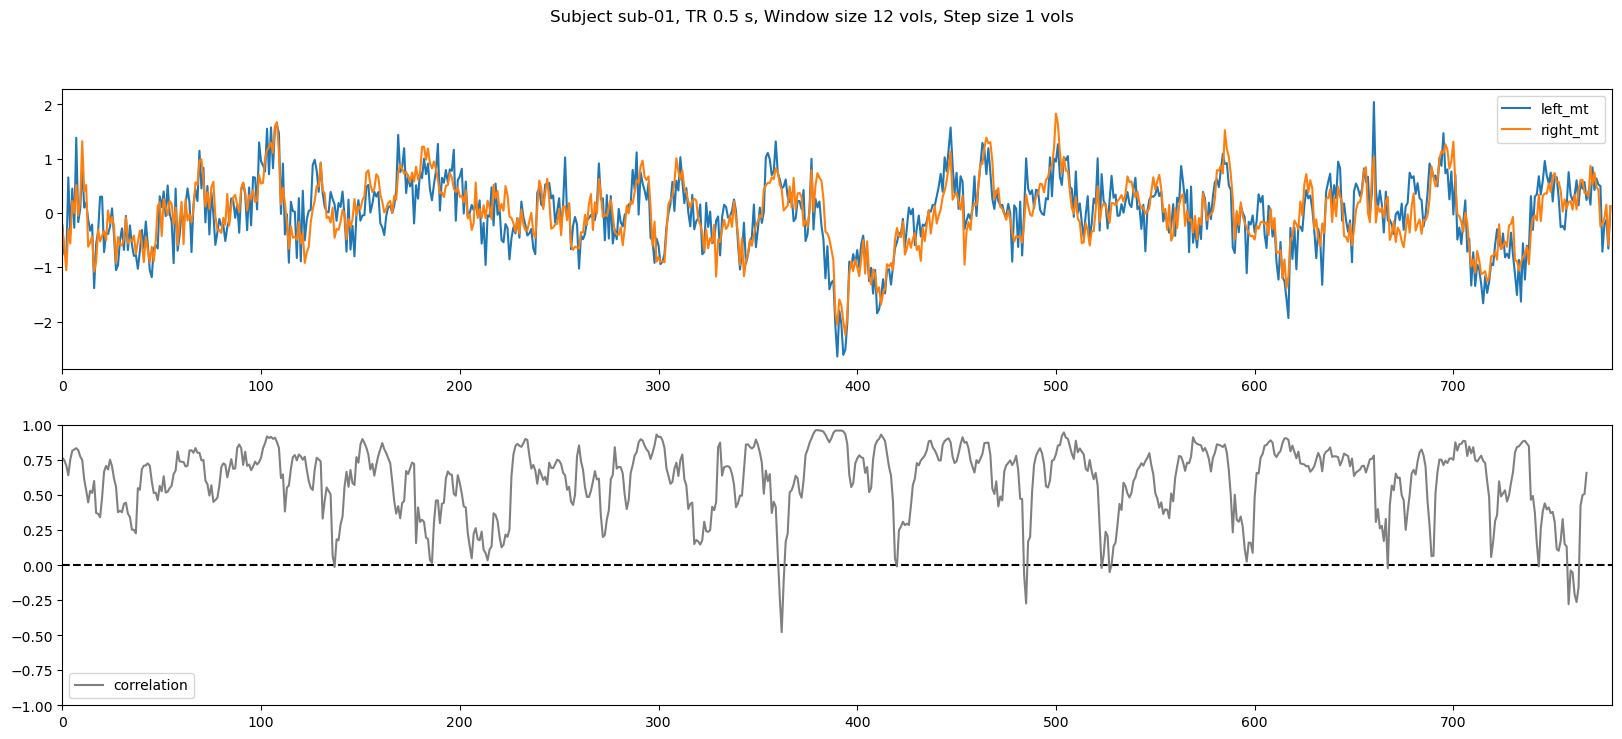

In [6]:
# Plot left mt, right mt and correlation between them as 3 subplots
df_idx = 0

n_volumes = df.loc[df_idx,'left_mt'].shape[0]

fig, ax = plt.subplots(2,1,figsize=(20,8))
ax[0].plot(df.loc[df_idx,'left_mt'],label='left_mt')
ax[0].plot(df.loc[df_idx,'right_mt'],label='right_mt')
ax[0].legend()
ax[0].set_xlim([0,n_volumes])
ax[1].hlines(0,0,n_volumes,linestyle='dashed',color='black')
ax[1].plot(df.loc[df_idx,'corr_mt'],label='correlation',color='grey')
ax[1].legend()
ax[1].set_xlim([0,n_volumes])
ax[1].set_ylim([-1,1])

fig.suptitle(f"Subject {df.loc[df_idx,'subject']}, TR {df.loc[df_idx,'tr']} s, Window size 12 vols, Step size 1 vols")

# centering at switches

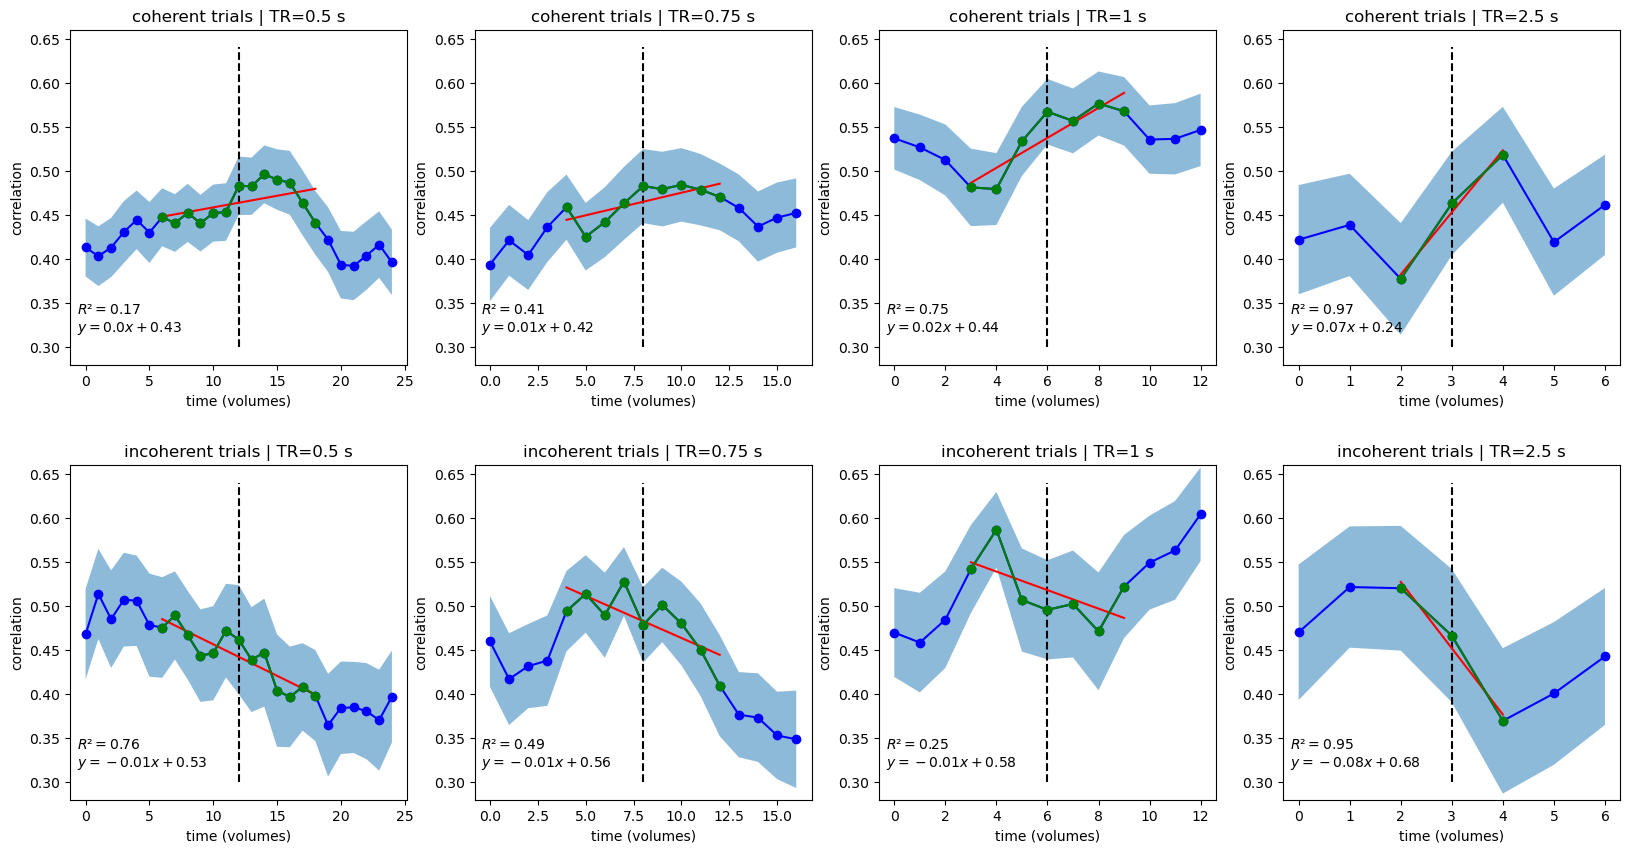

In [7]:
trial_list = ['coherent','incoherent']
half_window_size_list = [6,4,3,1]
roi = 'mt'

# initialize figure with 4x2 subplot
fig, ax = plt.subplots(2,4,figsize=(20,10))
plt.subplots_adjust(hspace=0.3)

for tr_idx,tr in enumerate(tr_list):

    window_size_tr = window_size_tr_list[tr_idx]

    for trial_idx,trial in enumerate(trial_list):

        # fetch correlation values for this tr, roi and trial
        aux = df.loc[df['tr']==tr,f'corr_{roi}_{trial}']

        # concatenate all rows
        aux = np.concatenate(aux.values)
        n_samples = aux.shape[0]

        # plot mean and std of aux in subplot
        plt.sca(ax[trial_idx,tr_idx])
        plt.plot(np.mean(aux,axis=0),color='blue', marker='o')
        plt.fill_between(range(aux.shape[1]),np.mean(aux,axis=0)-np.std(aux,axis=0)/np.sqrt(n_samples),np.mean(aux,axis=0)+np.std(aux,axis=0)/np.sqrt(n_samples),alpha=0.5)
        plt.vlines(window_size_tr,0.3,0.64,linestyle='dashed',color='black')
        #plt.text(8.5,0.7,trial)
        plt.ylabel('correlation')
        plt.xlabel('time (volumes)')
        plt.title(f"{trial} trials | TR={tr} s")

        # add linear regression line   
        y = np.mean(aux,axis=0)
        f = half_window_size_list[tr_idx]

        if tr==2.5:
            y = y[window_size_tr-f:window_size_tr+f+1] # pick window for regression
            x = np.arange(f+1,f+window_size_tr+1)
        else:
            y = y[window_size_tr-f:window_size_tr+f+1] # pick window for regression
            x = np.arange(f,f+y.shape[0])

        # linear regression
        x1 = sm.add_constant(x)

        # fit linear regression model
        model = sm.OLS(y, x1).fit()

        m = model.params[1]
        b = model.params[0]
        
        # plot
        plt.plot(x, m*x + b,color='red')
        plt.plot(x,y,color='green',marker='o')

        # add text with R squared and p value
        plt.text(0.02,0.1,f"$R\u00b2={round(model.rsquared_adj,2)}$\n$y={round(m,2)}x + {round(b,2)}$",transform=ax[trial_idx,tr_idx].transAxes)

        plt.ylim([0.28,0.66])

# dataframe manipulations...

In [8]:
from statannotations.Annotator import Annotator
from itertools import combinations

TRs = [0.5, 0.75, 1 , 2.5]
TR_pairs = list(combinations(TRs, r=2))

In [9]:
# convert n_ps_detected_mt_coherent to percentage
df['n_ps_detected_mt_coherent_percent'] = df['n_ps_detected_mt_coherent']*100
df['n_ps_detected_mt_incoherent_percent'] = df['n_ps_detected_mt_incoherent']*100

In [10]:
# average non zero values of feedback_mt_indexoffirstone_incoherent per subject for each TR
df['feedback_mt_indexoffirstone_coherent_mean'] = df['feedback_mt_indexoffirstone_coherent'].apply(lambda x: np.mean(x[np.nonzero(x)]))
df['feedback_mt_indexoffirstone_incoherent_mean'] = df['feedback_mt_indexoffirstone_incoherent'].apply(lambda x: np.mean(x[np.nonzero(x)]))

# convert indexes to seconds based on TR
df['feedback_mt_indexoffirstone_coherent_mean_secs'] = df['feedback_mt_indexoffirstone_coherent_mean'] * df['tr']
df['feedback_mt_indexoffirstone_incoherent_mean_secs'] = df['feedback_mt_indexoffirstone_incoherent_mean'] * df['tr']

/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


In [13]:
# create new dataframe with df['feedback_mt_indexoffirstone_coherent_mean_secs'] and df['feedback_mt_indexoffirstone_incoherent_mean_secs']
# with a new column named trial type with coeherent and incoherent and the tr as a column

df2 = pd.DataFrame(columns=['subject','tr','run','trial_type','total_number', 'n_ps_detected_mt_percent','feedback_mt_indexoffirstone_mean_secs'])

for ss,subject in enumerate(subject_list):
    
        for tt,tr in enumerate(tr_list):
    
            for rr,run in enumerate(run_list):

                df2.loc[len(df2)] = [subject, tr, run, 'coherent',   df.loc[(df['subject']==subject) & (df['tr']==tr) & (df['run']==run),'n_coherent'].values[0], df.loc[(df['subject']==subject) & (df['tr']==tr) & (df['run']==run),'n_ps_detected_mt_coherent_percent'].values[0], df.loc[(df['subject']==subject) & (df['tr']==tr) & (df['run']==run),'feedback_mt_indexoffirstone_coherent_mean_secs'].values[0]]
                df2.loc[len(df2)] = [subject, tr, run, 'incoherent',  df.loc[(df['subject']==subject) & (df['tr']==tr) & (df['run']==run),'n_incoherent'].values[0], df.loc[(df['subject']==subject) & (df['tr']==tr) & (df['run']==run),'n_ps_detected_mt_incoherent_percent'].values[0], df.loc[(df['subject']==subject) & (df['tr']==tr) & (df['run']==run),'feedback_mt_indexoffirstone_incoherent_mean_secs'].values[0]]




In [14]:
df2

,subject,tr,run,trial_type,total_number,n_ps_detected_mt_percent,feedback_mt_indexoffirstone_mean_secs
0,sub-01,0.50,UA,coherent,7,85.714286,4.166667
1,sub-01,0.50,UA,incoherent,2,100.000000,1.500000
2,sub-01,0.75,UA,coherent,7,57.142857,3.375000
3,sub-01,0.75,UA,incoherent,6,83.333333,5.550000
4,sub-01,1.00,UA,coherent,8,62.500000,2.200000
...,...,...,...,...,...,...,...
115,sub-23,0.75,UA,incoherent,0,0.000000,NaN
116,sub-23,1.00,UA,coherent,8,75.000000,1.666667
117,sub-23,1.00,UA,incoherent,0,0.000000,NaN
118,sub-23,2.50,UA,coherent,5,40.000000,5.000000


## Number of switches

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

TR 0.5
Ttest_indResult(statistic=4.176402683407139, pvalue=0.00026139860052108667)
TR 0.75
Ttest_indResult(statistic=2.515942035934202, pvalue=0.01788334335615075)
TR 1
Ttest_indResult(statistic=3.216075840633898, pvalue=0.003269274877030194)
TR 2.5
Ttest_indResult(statistic=2.940700797365258, pvalue=0.006501497936238892)


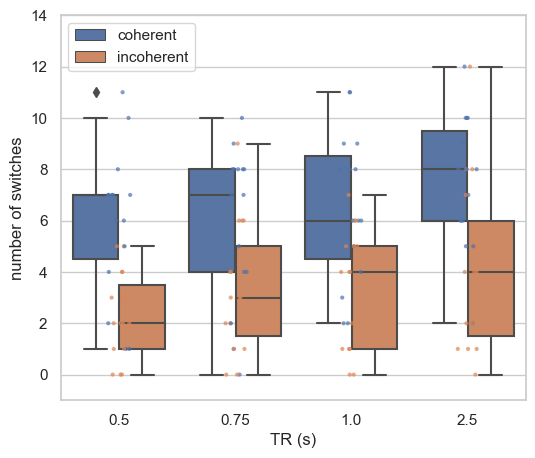

In [33]:
fig = plt.figure(figsize=(6,5))
cmap = sns.color_palette()
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="total_number",
            hue="trial_type", palette=cmap,
            data=df2)

# overlay jittered data points
sns.stripplot(x='tr',y='total_number',data=df2,hue='trial_type',jitter=True,alpha=0.7,size=3)

ax.set_ylabel('number of switches')
ax.set_xlabel('TR (s)')
ax.set_ylim([-1,14])
#ax.set_yticks([0,20,40,60,80,100])

annotator = Annotator(ax, TR_pairs, data=df2[df2['trial_type']=='coherent'], x='tr', y='total_number', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni',
                     line_offset_to_group=10, color=cmap[0], hide_non_significant=True)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="",loc='upper left')


In [34]:
# summary of df2['total_number'] per tr and trial type
df2.groupby(['tr','trial_type'])['total_number'].describe()

# test for difference between coherent and incoherent trials for each TR
from scipy.stats import ttest_ind

for tr in tr_list:
    print(f"TR {tr}")
    print(ttest_ind(df2.loc[(df2['tr']==tr) & (df2['trial_type']=='coherent'),'total_number'],df2.loc[(df2['tr']==tr) & (df2['trial_type']=='incoherent'),'total_number']))

TR 0.5
Ttest_indResult(statistic=4.176402683407139, pvalue=0.00026139860052108667)
TR 0.75
Ttest_indResult(statistic=2.515942035934202, pvalue=0.01788334335615075)
TR 1
Ttest_indResult(statistic=3.216075840633898, pvalue=0.003269274877030194)
TR 2.5
Ttest_indResult(statistic=2.940700797365258, pvalue=0.006501497936238892)


In [38]:
# grand average and standard dev of total_number
df2['total_number'].describe()

count    120.000000
mean       4.891667
std        3.156415
min        0.000000
25%        2.000000
50%        5.000000
75%        7.000000
max       12.000000
Name: total_number, dtype: float64

# perceptual switch detection rate

In [13]:
# replace zeros with NaNs in n_ps_detected_mt_percent
# df2['n_ps_detected_mt_percent'] = df2['n_ps_detected_mt_percent'].replace(0,np.nan)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:5.587e-04 U_stat=2.065e+02
0.75 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:7.362e-03 U_stat=1.900e+02
0.5 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.548e-03 U_stat=1.945e+02


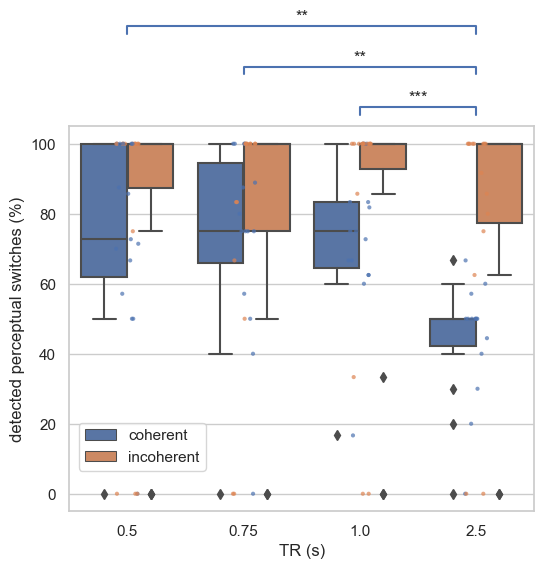

In [21]:
# figure - boxplot of feedback_mt_indexoffirstone_incoherent_mean_secs per TR across subjects using seaborn
fig = plt.figure(figsize=(6,5))
cmap = sns.color_palette()
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="n_ps_detected_mt_percent",
            hue="trial_type", palette=cmap,
            data=df2)

# overlay jittered data points
sns.stripplot(x='tr',y='n_ps_detected_mt_percent',data=df2,hue='trial_type',jitter=True,alpha=0.7,size=3)

ax.set_ylabel('detected perceptual switches (%)')
ax.set_xlabel('TR (s)')
ax.set_yticks([0,20,40,60,80,100])

annotator = Annotator(ax, TR_pairs, data=df2[df2['trial_type']=='coherent'], x='tr', y='n_ps_detected_mt_percent', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni',
                     line_offset_to_group=10, color=cmap[0], hide_non_significant=True)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="",loc='upper left', bbox_to_anchor=(0.005, 0.25))

In [15]:
# boxplot of n_ps_detected_mt_coherent per TR across subjects
#d = df.loc[df['tr']==1,'n_ps_detected_mt_coherent']

#fig, ax = plt.subplots(1,2,figsize=(10,5),sharey=True)

#sns.set(style="whitegrid")



# sns.boxplot(x='tr',y='n_ps_detected_mt_coherent_percent',data=df,ax=ax[0],palette="vlag")
# sns.boxplot(x='tr',y='n_ps_detected_mt_incoherent_percent',data=df,ax=ax[1],palette="vlag")

# ax[0].set_title('switches to coherent')
# ax[1].set_title('switches to incoherent')
# ax[0].set_ylabel('percentage of identified perceptual switches')
# ax[1].set_ylabel('')

# ax[0].set_xlabel('TR (s)')
# ax[1].set_xlabel('TR (s)')

# ax[0].set_yticks([0,20,40,60,80,100])
# ax[1].set_yticks([0,20,40,60,80,100])

# annotator = Annotator(ax[0], TR_pairs, data=df, x='tr', y='n_ps_detected_mt_coherent', order=TRs)
# annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=1, comparisons_correction='bonferroni', hide_non_significant=True)
# annotator.apply_and_annotate()

# annotator = Annotator(ax[1], TR_pairs, data=df, x='tr', y='n_ps_detected_mt_incoherent', order=TRs)
# annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=1, comparisons_correction='bonferroni', hide_non_significant=True)
# annotator.apply_and_annotate()

# Perceptual switch detection speed

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.174e-03 U_stat=1.565e+02
0.75 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.528e-04 U_stat=1.320e+02
0.5 vs. 2.5: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.850e-05 U_stat=9.350e+01


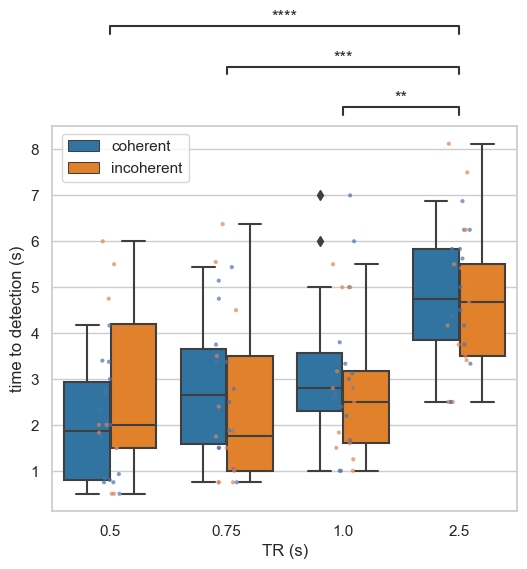

In [17]:
# figure - boxplot of feedback_mt_indexoffirstone_incoherent_mean_secs per TR across subjects using seaborn
fig = plt.figure(figsize=(6,5))
sns.set(style="whitegrid")

# boxplot with coherent and incoherent trials together grouped by tr
ax = sns.boxplot(x="tr", y="feedback_mt_indexoffirstone_mean_secs",
                 palette=cmap,
            hue="trial_type",
            data=df2)

# overlay jittered data points
sns.stripplot(x='tr',y='feedback_mt_indexoffirstone_mean_secs',data=df2,hue='trial_type',jitter=True,alpha=0.7,size=3)

ax.set_ylabel('time to detection (s)')
ax.set_xlabel('TR (s)')

annotator = Annotator(ax, TR_pairs, data=df2, x='tr', y='feedback_mt_indexoffirstone_mean_secs', order=TRs)
annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', verbose=1, comparisons_correction='bonferroni',hide_non_significant=True, line_offset_to_group=10)
annotator.apply_and_annotate()

# set legend to the first two handles and position to y = 8
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:2], labels[0:2], title="",loc='upper left', bbox_to_anchor=(0.005, 1))